# COICOP — classifying short Hebrew item names with a multilingual encoder

This notebook adapts the [`text_classifier`](../../README.md) package to a very
different shape of problem from the [CLINC150 demo](../clinc150/): **short,
messy product names written in Hebrew**, classified into the international
[**COICOP 2018**](https://unstats.un.org/unsd/classifications/Econ) taxonomy of
household consumption (the codes national statistics offices use for CPI and
household-expenditure surveys).

Two things make this interesting:

1. **Cross-lingual.** The item names are Hebrew (`עוגיות סנדביץ`, `שמן שומשום`,
   `דלוורדה ניוקי`); the COICOP labels are English. A **multilingual** sentence
   encoder bridges the two in a shared embedding space.
2. **No labels yet.** We have the class *descriptions* and a list of *unlabeled*
   items. That rules out training the fusion model (which learns from labeled
   examples). So we run the package's encoder in **zero-shot retrieval** mode —
   the item ↔ class-description similarity signal, signal #1 of the five — and
   abstain with a confidence floor, the same human-in-the-loop story as CLINC150.

> **What changes once you have labels.** As soon as a few items per COICOP class
> are confirmed, the full `TrainingPipeline` (prototypes, kNN, BM25, XGBoost
> fusion, isotonic calibration, tuned abstention) applies unchanged — see the
> final section and the CLINC150 notebook. Zero-shot is the floor, not the ceiling.

## 1. Setup

Unlike the CLINC150 demo, this one is **not** offline: a real multilingual
bi-encoder is the whole point, so the notebook downloads one model (~1 GB the
first time, then cached) and needs `torch`.

```bash
pip install .                 # from the repo root (brings in sentence-transformers)
pip install pandas openpyxl matplotlib jupyter
```

In [1]:
import logging
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import text_classifier
from text_classifier.infrastructure.encoder import SentenceTransformerEncoder

logging.getLogger("text_classifier").setLevel(logging.WARNING)
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Hebrew prints right-to-left in most notebook frontends; nothing special needed.
print("text_classifier version:", text_classifier.__version__)
print("Python:", sys.version.split()[0])

text_classifier version: 0.1.0
Python: 3.11.15


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    # Walk upward until we find the package root, so the notebook runs from the
    # repo root or from this examples/ directory.
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "text_classifier").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from %s" % here)

REPO_ROOT = find_repo_root()
EXAMPLE_DIR = REPO_ROOT / "examples" / "coicop_hebrew"
BUILD = EXAMPLE_DIR / "build"          # downloaded workbook + classes.csv (git-ignored)

print("repository root :", REPO_ROOT)
print("example dir     :", EXAMPLE_DIR)
print("build dir       :", BUILD)

repository root : /home/user/Hybrid-retrieval-fusion-text-classifier
example dir     : /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew
build dir       : /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/build


## 2. The COICOP class taxonomy

`prepare.py` downloads the UN Statistics Division's **COICOP 2018 hierarchies &
mappings** workbook once and turns one level of the hierarchy into the package's
`classes.csv` shape (`key,description`). COICOP nests four levels — division
(`01`), group (`01.1`), class (`01.1.1`), subclass (`01.1.1.1`). We emit the
**subclass** level, the granularity grocery products live at, and — because every
item here is food — keep **division 01** (food and non-alcoholic beverages).

Each `description` folds the official *title* together with the *intro* and
*includes* notes (e.g. "cornflakes, oatmeal, muesli, granola"). That concrete
product vocabulary is exactly what an item name echoes, so a richer description
is a stronger retrieval target — the first thing to tune for production.

In [3]:
cmd = [sys.executable, str(EXAMPLE_DIR / "prepare.py"),
       "--out", str(BUILD), "--level", "4", "--divisions", "01"]
print("$", " ".join(cmd), "\n")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit("prepare.py failed — see the error above.")

$ /usr/bin/python3 /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/prepare.py --out /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/build --level 4 --divisions 01 



wrote    69 rows -> /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/build/classes.csv

69 COICOP level-4 classes (division(s) 01).
Next: open coicop_hebrew_classification.ipynb, or feed classes.csv to the library.



In [4]:
classes = pd.read_csv(BUILD / "classes.csv")
# The human-readable title is the part of the description before the first em dash.
classes["title"] = classes["description"].str.split(" — ").str[0]
print(f"{len(classes)} COICOP subclasses in division 01 (food & non-alcoholic beverages)\n")
display(classes[["key", "title"]].head(12))
print("\nExample of a full (rich) description used for retrieval:\n")
print(classes.loc[classes.key == "01.1.1.4", "description"].iloc[0])

69 COICOP subclasses in division 01 (food & non-alcoholic beverages)



,key,title
0,01.1.1.1,Cereals
1,01.1.1.2,Flour of cereals
2,01.1.1.3,Bread and bakery products
3,01.1.1.4,Breakfast cereals
4,01.1.1.5,"Macaroni, noodles, couscous and similar pasta ..."
5,01.1.1.9,Other milled cereal and grain products
6,01.1.2.1,Live land animals
7,01.1.2.2,"Meat, fresh, chilled or frozen"
8,01.1.2.3,"Meat, dried, salted, in brine or smoked"
9,01.1.2.4,"Offal, blood and other parts of slaughtered an..."



Example of a full (rich) description used for retrieval:

Breakfast cereals — Includes: cornflakes, oatmeal and oat flakes, muesli, granola and puffed cereals including puffed rice cakes breakfast cereals with nuts or dried fruit


## 3. The items to classify

`items.csv` has a single **`name`** column of short Hebrew product names — the
file shape you'd export from a catalog or receipt. These are *unlabeled*: our
job is to attach a COICOP code to each.

In [5]:
items = pd.read_csv(EXAMPLE_DIR / "items.csv")
names = items["name"].astype(str).tolist()
print(f"{len(names)} items to classify\n")
display(items)

15 items to classify



,name
0,עוגיות סנדביץ
1,וויט פיש
2,שמן שומשום
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר
4,דייסת שיבולת שועל תפוחים וקינמון 400גר
5,דגני קורנפלקס בדבש 300גר
6,ג'לי בלי חמוץ 50גר
7,ג'לי בלי שיק פירות 50גר
8,ג'לי בלי שייק פירות 100גר
9,דרוסטה שוקולד לבן 100 גרם


## 4. A multilingual encoder (Hebrew + English)

The package's `SentenceTransformerEncoder` wraps any
[sentence-transformers](https://www.sbert.net) model and returns **L2-normalized**
embeddings (so a dot product is cosine similarity — a core invariant of the
package). We pick a model that is strong in **both Hebrew and English** so the
Hebrew item and the English class label land near each other:

| model | size | notes |
|---|---|---|
| `sentence-transformers/LaBSE` *(default here)* | ~1.8 GB | 109-language bitext model trained on translation pairs; the most robust **cross-lingual** matcher of the four for these Hebrew↔English items |
| `paraphrase-multilingual-mpnet-base-v2` | ~1.1 GB | 50+ languages; good and a bit lighter |
| `paraphrase-multilingual-MiniLM-L12-v2` | ~470 MB | faster/smaller, a touch weaker |
| `intfloat/multilingual-e5-base` | ~1.1 GB | strong in-language retrieval, but expects `"query:"`/`"passage:"` prefixes and was less discriminative on these transliterated brand names |

We default to **LaBSE**: it was trained specifically to put a sentence and its
translation next to each other, which is exactly the Hebrew-item ↔ English-label
bridge we need. The first call downloads and caches the weights.

In [6]:
MODEL_NAME = "sentence-transformers/LaBSE"
print(f"loading {MODEL_NAME} (first run downloads the weights) ...")
encoder = SentenceTransformerEncoder.load(MODEL_NAME)
# Sanity check: a Hebrew word and its English meaning should be close.
probe = encoder.encode(["שוקולד", "chocolate", "car tire"])
print("cos(שוקולד, chocolate) =", round(float(probe[0] @ probe[1]), 3))
print("cos(שוקולד, car tire) =", round(float(probe[0] @ probe[2]), 3))

loading sentence-transformers/LaBSE (first run downloads the weights) ...


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3387.58it/s]

cos(שוקולד, chocolate) = 0.944
cos(שוקולד, car tire) = 0.314


## 5. Zero-shot classification by description similarity

With no labeled examples, only one of the five retrieval signals is available:
**item ↔ class-description** cosine similarity. We embed every COICOP description
and every item once, then for each item rank the classes by similarity. Because
the embeddings are unit-norm, the whole thing is a single matrix product —
`items @ classes.T` — with no per-row Python loop, honoring the package's
vectorization convention.

In [7]:
class_emb = encoder.encode(classes["description"].tolist())   # (n_classes, dim)
item_emb = encoder.encode(names)                              # (n_items, dim)

sim = item_emb @ class_emb.T                                  # cosine, (n_items, n_classes)
order = np.argsort(-sim, axis=1)                              # best class first, per item

top1 = order[:, 0]
top2 = order[:, 1]
results = pd.DataFrame({
    "item": names,
    "COICOP": classes["key"].to_numpy()[top1],
    "title": classes["title"].to_numpy()[top1],
    "score": sim[np.arange(len(names)), top1].round(3),
    "margin": (sim[np.arange(len(names)), top1] - sim[np.arange(len(names)), top2]).round(3),
    "runner_up": classes["key"].to_numpy()[top2] + " " + classes["title"].to_numpy()[top2],
})
display(results)

,item,COICOP,title,score,margin,runner_up
0,עוגיות סנדביץ,01.1.1.3,Bread and bakery products,0.376,0.029,01.1.8.9 Other sugar confectionery and dessert...
1,וויט פיש,01.1.3.2,"Fish, dried, salted, in brine or smoked",0.347,0.006,"01.1.3.1 Fish, live, fresh, chilled or frozen"
2,שמן שומשום,01.1.5.1,Vegetable oils,0.496,0.038,01.1.5.2 Butter and other oils and fats derive...
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר,01.1.8.6,"Ice, ice cream and sorbets",0.296,0.001,01.1.8.1 Cane sugar and beet sugar
4,דייסת שיבולת שועל תפוחים וקינמון 400גר,01.1.6.3,"Stone fruits and pome fruits, fresh",0.318,0.007,"01.1.8.3 Jams, marmalades, fruit jellies, puré..."
5,דגני קורנפלקס בדבש 300גר,01.1.1.4,Breakfast cereals,0.282,0.012,01.1.8.1 Cane sugar and beet sugar
6,ג'לי בלי חמוץ 50גר,01.1.6.6,"Fruits, frozen",0.196,0.006,01.2.1.0 Fruit and vegetable juices
7,ג'לי בלי שיק פירות 50גר,01.2.1.0,Fruit and vegetable juices,0.311,0.019,"01.1.6.6 Fruits, frozen"
8,ג'לי בלי שייק פירות 100גר,01.2.1.0,Fruit and vegetable juices,0.303,0.021,01.1.8.9 Other sugar confectionery and dessert...
9,דרוסטה שוקולד לבן 100 גרם,01.1.8.5,"Chocolate, cocoa and cocoa-based food products",0.344,0.006,01.2.4.0 Cocoa drinks


Read this by **score**, not just by the top guess. The clear, single-concept
items come back **confident and right**, cross-lingually and with zero labels:
`שמן שומשום` (sesame oil) → *Vegetable oils*, `וויט פיש` (white fish) → a *Fish*
subclass, `עוגיות סנדביץ` (sandwich cookies) → *Bread and bakery products*,
`שוקולד לבן` (white chocolate) → *Chocolate, cocoa and cocoa-based*.

The transliterated Italian pasta shapes (`ריגטוני`, `פטוצ'יני`, `טליאטלה`,
`ניוקי`) and the `ג'לי בלי` candy brand get the **lowest** scores — the model
genuinely doesn't recognize the words, and its similarity says so. A couple of
items sit in the murky middle: `קורנפלקס` (cornflakes) actually finds the right
class (*Breakfast cereals*) but only weakly, and `שוקולד חלב/לבן` (milk/white
chocolate) is pulled toward a dairy class by the word *milk*. That spread — high
and right, low and unknown, borderline and shaky — is exactly the structure a
confidence floor turns into accept/abstain decisions next. (`margin`, the gap to
the runner-up, is a second, complementary signal of how *decided* a guess is.)

## 6. Abstention — a confidence floor

The package's whole thesis is **knowing when not to answer**. Zero-shot, we don't
have a calibrated probability, but the raw top-1 similarity is a serviceable
confidence: items whose best class is still far away (an unfamiliar brand, a
non-food product, a typo) should be **routed to a human** instead of guessed.
We set an illustrative floor; in production you'd tune it on a labeled sample the
way `TrainingPipeline` tunes its threshold for a target accuracy.

In [8]:
THRESHOLD = 0.33    # illustrative cosine floor for LaBSE; tune on labeled data

results["decision"] = np.where(
    results["score"] >= THRESHOLD,
    results["COICOP"] + "  " + results["title"],
    "ABSTAIN → route to human",
)
n_acc = int((results["score"] >= THRESHOLD).sum())
print(f"threshold = {THRESHOLD}")
print(f"accepted  : {n_acc}/{len(results)}  ({100 * n_acc / len(results):.0f}% coverage)")
print(f"abstained : {len(results) - n_acc}/{len(results)}\n")
display(results[["item", "score", "margin", "decision"]])

threshold = 0.33
accepted  : 5/15  (33% coverage)
abstained : 10/15



,item,score,margin,decision
0,עוגיות סנדביץ,0.376,0.029,01.1.1.3 Bread and bakery products
1,וויט פיש,0.347,0.006,"01.1.3.2 Fish, dried, salted, in brine or smoked"
2,שמן שומשום,0.496,0.038,01.1.5.1 Vegetable oils
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר,0.296,0.001,ABSTAIN → route to human
4,דייסת שיבולת שועל תפוחים וקינמון 400גר,0.318,0.007,ABSTAIN → route to human
5,דגני קורנפלקס בדבש 300גר,0.282,0.012,ABSTAIN → route to human
6,ג'לי בלי חמוץ 50גר,0.196,0.006,ABSTAIN → route to human
7,ג'לי בלי שיק פירות 50גר,0.311,0.019,ABSTAIN → route to human
8,ג'לי בלי שייק פירות 100גר,0.303,0.021,ABSTAIN → route to human
9,דרוסטה שוקולד לבן 100 גרם,0.344,0.006,"01.1.8.5 Chocolate, cocoa and cocoa-based foo..."


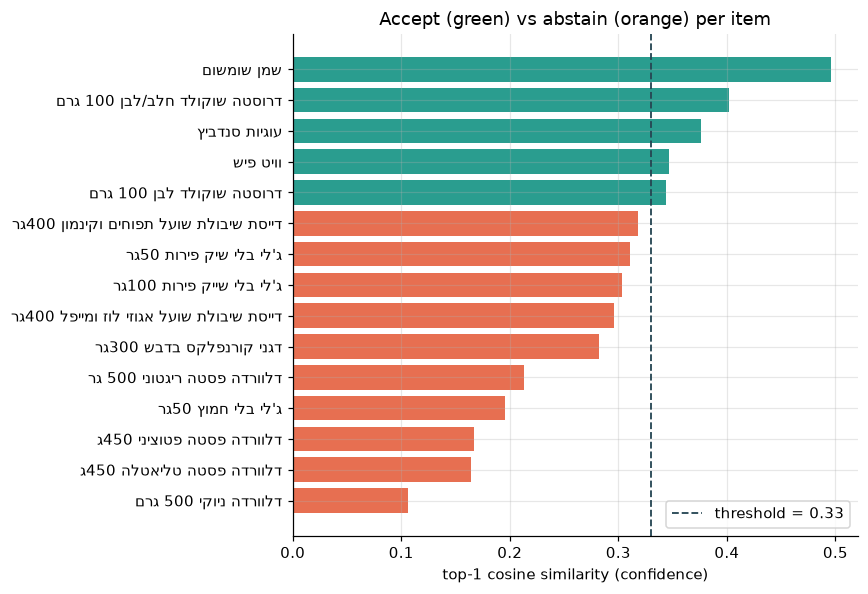

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
o = np.argsort(results["score"].to_numpy())
y = np.arange(len(o))
scores = results["score"].to_numpy()[o]
colors = ["#2a9d8f" if s >= THRESHOLD else "#e76f51" for s in scores]
ax.barh(y, scores, color=colors)
ax.axvline(THRESHOLD, color="#264653", ls="--", lw=1.2, label=f"threshold = {THRESHOLD}")
ax.set_yticks(y)
ax.set_yticklabels(results["item"].to_numpy()[o])
ax.set_xlabel("top-1 cosine similarity (confidence)")
ax.set_title("Accept (green) vs abstain (orange) per item")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. When labels arrive: a COICOP-like Hebrew taxonomy

Zero-shot is the **floor**. Everything above used one signal (item ↔ description)
and no training. Now suppose you have labels — but, realistically, labelled into
*your own* Hebrew retail taxonomy rather than COICOP itself.
[`data.csv`](data.csv) is exactly that: ~160k short Hebrew item names tagged into
**186 Hebrew retail categories** (`שוקולד`, `עוגיות וביסקוויטים`, `דגני בוקר`,
`אטריות, ספגטי וכדומה`, …) — a *COICOP-like* classification, not COICOP.

That's enough to train the **full pipeline** and light up the four signals that
were dark: class **prototypes** (mean embedding per class), **dense** and **BM25**
kNN over labelled examples, and the **BM25 description** match — fused by an
**XGBoost** model, **isotonic**-calibrated, with an abstention threshold **tuned
for a target accuracy**. BM25 in particular is a big lift here: Hebrew grocery
names share literal tokens (`שוקולד`, `פסטה`, `דייסת`), which exact-match retrieval
exploits directly. We train into the Hebrew taxonomy now, and come back to
targeting COICOP itself at the end.

In [10]:
from sklearn.model_selection import train_test_split
from text_classifier import (PipelineConfig, LabelSpace, ClassDefinition,
                             LabeledItem, TrainingPipeline, InferencePipeline)
from text_classifier.application.evaluation import evaluate_decisions

# Subsample knobs — kept modest so the notebook trains in a couple of minutes.
# Drop them (or raise them) to use more of the 186 classes / 160k rows.
MAX_CLASSES, PER_CLASS, SEED = 40, 60, 0

raw = pd.read_csv(EXAMPLE_DIR / "data.csv").rename(columns={"lbcItemName": "name"})
raw = raw[["name", "label"]].dropna(subset=["label"])
raw["name"] = raw["name"].astype(str).str.strip()
raw = raw[raw["name"].str.len() > 0].drop_duplicates(subset=["name"])
print(f"labelled rows: {len(raw):,}   distinct classes: {raw['label'].nunique()}")

# Keep the most frequent classes, capped per class, then a stratified 80/20 split.
top = raw["label"].value_counts().head(MAX_CLASSES).index
sub = raw[raw["label"].isin(top)].reset_index(drop=True)
sub = pd.concat([
    g.sample(min(len(g), PER_CLASS), random_state=SEED)
    for _, g in sub.groupby("label")
]).reset_index(drop=True)
train_df, test_df = train_test_split(
    sub, test_size=0.2, stratify=sub["label"], random_state=SEED)
print(f"using {sub['label'].nunique()} classes  ->  train={len(train_df)}  test={len(test_df)}")
display(sub["label"].value_counts().head(10).rename("n_items").to_frame())

labelled rows: 128,435   distinct classes: 186
using 40 classes  ->  train=1920  test=480


,n_items
label,
אבקות מרק ותבשילים מוכנים,60
"אטריות, ספגטי וכדומה",60
אמצעי ניקוי אחרים כגון ספוגית לרחיצת הכלים ומגבות נייר,60
בצק ומוצרי בצק קפואים ומצוננים,60
בשר בקר טרי,60
גבינות לבנות למריחה,60
גלידות ושלגונים,60
דגני בוקר,60
ופלים,60


## 8. Train the full pipeline

Same `TrainingPipeline` as the CLINC150 demo — only the data and the encoder
differ. For a fast, runnable demo we use the lighter multilingual
`paraphrase-multilingual-MiniLM-L12-v2`; the OOF training loop re-encodes each
fold, so the heavier LaBSE would be several times slower here (swap it back in
for a production run). The class *description* is just the Hebrew category name —
there's no richer gloss to fold in, but with real labelled examples the
prototype/kNN/BM25 signals do the heavy lifting the description carried alone.

In [11]:
HEBREW_MODEL_DIR = BUILD / "hebrew_model"
label_space_he = LabelSpace([ClassDefinition(k, k) for k in sorted(sub["label"].unique())])
train_items = [LabeledItem(t, l) for t, l in zip(train_df["name"], train_df["label"])]

cfg = PipelineConfig()
cfg.encoder.kind = "sentence-transformers"
cfg.encoder.model_name_or_path = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
cfg.training.target_precision = 0.90    # accept only where accuracy is expected >= 90%

print(f"training on {len(train_items)} items across {label_space_he.size} classes ...")
artifacts, report = TrainingPipeline(cfg).run(
    train_items, label_space_he, output_dir=str(HEBREW_MODEL_DIR))
print("done.")

pd.Series({
    "candidate recall":       report.candidate_recall,
    "coverage":               report.coverage,
    "accuracy on accepted":   report.accuracy_on_accepted,
    "accuracy if no abstain": report.accuracy_if_no_abstain,
}).round(3).to_frame("test fold")

training on 1920 items across 40 classes ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2458.94it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3000.78it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

done.


,test fold
candidate recall,0.974
coverage,0.789
accuracy on accepted,0.851
accuracy if no abstain,0.758


**Candidate recall** is the ceiling: the fraction of items whose true class made
the candidate shortlist at all. **Accuracy on accepted** is what the caller
actually experiences on the items the model *doesn't* abstain on, and it sits
well above **accuracy if no abstain** — that gap is the abstention policy buying
precision by declining the hard cases.

## 9. Held-out evaluation

Load the saved model back through `InferencePipeline` and score the untouched
test split — coverage, accuracy-on-accepted, and calibration (Brier / ECE), the
same battery as the CLINC150 demo.

In [12]:
pipe_he = InferencePipeline.from_directory(str(HEBREW_MODEL_DIR))
keys_he = pipe_he.label_space.keys
key_to_idx = {k: i for i, k in enumerate(keys_he)}

test_preds = pipe_he.predict(list(test_df["name"]))
confidence = np.array([p.confidence for p in test_preds])
accepted   = np.array([not p.abstained for p in test_preds])
correct    = np.array([p.top_key == l for p, l in zip(test_preds, test_df["label"])])

ev = evaluate_decisions(
    confidence=confidence, correct=correct, accepted=accepted,
    pred_idx=np.array([key_to_idx.get(p.top_key, -1) for p in test_preds]),
    true_idx=np.array([key_to_idx[l] for l in test_df["label"]]),
    keys=keys_he,
)
o, c = ev["overall"], ev["calibration"]
pd.Series({
    "items evaluated":        o["n_items"],
    "coverage":               o["coverage"],
    "accuracy on accepted":   o["accuracy_on_accepted"],
    "accuracy if no abstain": o["accuracy_if_no_abstain"],
    "Brier score":            c["brier_score"],
    "expected calib. error":  c["expected_calibration_error"],
}).round(3).to_frame("held-out test")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2671.49it/s]

,held-out test
items evaluated,480.000
coverage,0.817
accuracy on accepted,0.888
accuracy if no abstain,0.785
Brier score,0.120
expected calib. error,0.060


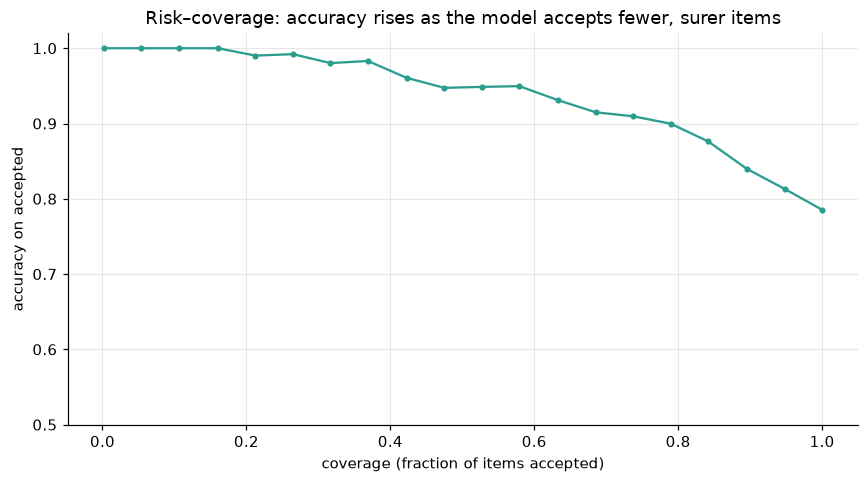

In [13]:
rc = pd.DataFrame(ev["risk_coverage_curve"])
fig, ax = plt.subplots()
ax.plot(rc["coverage"], rc["accuracy"], marker=".", color="#2a9d8f")
ax.set_xlabel("coverage (fraction of items accepted)")
ax.set_ylabel("accuracy on accepted")
ax.set_title("Risk–coverage: accuracy rises as the model accepts fewer, surer items")
ax.set_ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

## 10. Back to our 15 items — supervision closes the zero-shot gaps

The real test: re-run the original 15 Hebrew names through the **supervised**
model and put them next to the zero-shot COICOP decisions from section 6. The
transliterated pastas and `ניוקי` that the encoder *abstained* on with no labels
now land confidently in `אטריות, ספגטי וכדומה`, because the model has seen
thousands of similar Hebrew grocery names. Items whose true class fell outside
the subsampled label set still (correctly) abstain — coverage of the taxonomy is
its own knob.

In [14]:
supervised = pipe_he.predict(names)
compare = pd.DataFrame({
    "item": names,
    "zero-shot (COICOP)": [
        (r.title if r.score >= THRESHOLD else "— abstain —")
        for r in results.itertuples()
    ],
    "supervised (Hebrew taxonomy)": [
        (p.predicted_key if not p.abstained else "— abstain —") for p in supervised
    ],
    "conf": [round(p.confidence, 2) for p in supervised],
})
display(compare)

,item,zero-shot (COICOP),supervised (Hebrew taxonomy),conf
0,עוגיות סנדביץ,Bread and bakery products,עוגיות וביסקוויטים,0.96
1,וויט פיש,"Fish, dried, salted, in brine or smoked",— abstain —,0.45
2,שמן שומשום,Vegetable oils,שמן,1.00
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר,— abstain —,— abstain —,0.45
4,דייסת שיבולת שועל תפוחים וקינמון 400גר,— abstain —,משקאות קלים לא תוססים,0.62
5,דגני קורנפלקס בדבש 300גר,— abstain —,דגני בוקר,0.92
6,ג'לי בלי חמוץ 50גר,— abstain —,סוכריות וממתקים שונים,0.82
7,ג'לי בלי שיק פירות 50גר,— abstain —,סוכריות וממתקים שונים,0.92
8,ג'לי בלי שייק פירות 100גר,— abstain —,סוכריות וממתקים שונים,0.92
9,דרוסטה שוקולד לבן 100 גרם,"Chocolate, cocoa and cocoa-based food products",שוקולד,0.81


## 11. From the Hebrew taxonomy to COICOP itself

We just trained into a *COICOP-like* Hebrew taxonomy. Two routes carry this the
last step to **COICOP codes**:

1. **Crosswalk the labels.** Map each Hebrew category to a COICOP code (many-to-one
   is fine; where a Hebrew class spans several COICOP subclasses, map at the
   coarser COICOP *class* level). Composing `item → Hebrew label → COICOP` turns
   this dataset into COICOP-labelled training data, and the same pipeline retrains
   straight onto COICOP keys.
2. **Fine-tune the encoder** on these `(item, Hebrew-description)` pairs — no
   crosswalk needed — to teach it the domain vocabulary (`ריגטוני` is pasta,
   `דרוסטה` is chocolate), then reuse it in the section-5 zero-shot COICOP step.
   That directly lifts the one signal available without COICOP labels.

### Takeaways

- A multilingual encoder classifies **Hebrew** names against **English** COICOP
  labels zero-shot, with no translation step — the shared space does the work.
- A **confidence floor** delivers human-in-the-loop behaviour before any labels
  exist; once labels arrive, **calibration** makes that floor principled and the
  **fusion of five signals** lifts both coverage and accuracy.
- Labels in a *similar* taxonomy are highly reusable: they train the full pipeline
  as-is, and bridge to COICOP via a crosswalk or encoder fine-tuning.